This project processes Amazon cell phone and accessory reviews to automatically extract structured knowledge from unstructured text. First, the raw review data is loaded and cleaned through tokenization and preprocessing to prepare it for linguistic analysis. Then, using dependency parsing techniques, the system identifies meaningful entities in each sentence, typically representing subjects and objects, and extracts the relationships between them based on syntactic patterns in the text. These extracted entity–relation pairs are then aggregated from a subset of the dataset to form structured triples. Next, a knowledge graph is constructed using these triples, where entities are represented as nodes and their relationships as directed edges, enabling a structured representation of user opinions and interactions. Finally, the graph is visualized using network analysis tools, including a focused subgraph that highlights specific relations such as “need,” allowing for clearer interpretation of common patterns and dependencies within the reviews.

By Shayan Rokhva

In [ ]:
import pandas as pd
import json
import gensim

df = pd.read_json("/kaggle/input/amazon-reviews/Cell_Phones_and_Accessories_5.json", lines=True)
df

In [2]:
# apply preprocessing (lowercase, tokenize, remove punctuation)
review_text = df['reviewText'].apply(gensim.utils.simple_preprocess)

In [3]:
# regex (text processing)
import re

# data handling
import pandas as pd

# HTML parsing
import bs4

# HTTP requests
import requests

# NLP library
import spacy
from spacy import displacy  # visualization

# load English NLP model
nlp = spacy.load('en_core_web_sm')

# pattern matching in text
from spacy.matcher import Matcher 
from spacy.tokens import Span 

# graph creation
import networkx as nx

# plotting graphs
import matplotlib.pyplot as plt

# progress bar
from tqdm import tqdm

# show full text in dataframe cells
pd.set_option('display.max_colwidth', 200)

# enable inline plots (Jupyter)
%matplotlib inline

In [4]:
# check type of processed reviews
type(review_text)

# process a sample sentence with spaCy (dependency parsing)
doc = nlp("the drawdown process is governed by astm standard d823")

# print each token and its dependency role
for tok in doc:
  print(tok.text, "...", tok.dep_)

the ... det
drawdown ... amod
process ... nsubjpass
is ... auxpass
governed ... ROOT
by ... agent
astm ... compound
standard ... compound
d823 ... pobj


In [5]:
# extract subject (ent1) and object (ent2) from a sentence
def get_entities(sent):
  ent1 = ""  # subject
  ent2 = ""  # object

  # keep track of previous token info
  prv_tok_dep = ""
  prv_tok_text = ""

  prefix = ""   # compound words
  modifier = "" # modifiers (e.g., adjectives)

  for tok in nlp(sent):
    # skip punctuation
    if tok.dep_ != "punct":

      # handle compound words (e.g., "phone case")
      if tok.dep_ == "compound":
        prefix = tok.text
        if prv_tok_dep == "compound":
          prefix = prv_tok_text + " " + tok.text
      
      # handle modifiers (e.g., "big phone")
      if tok.dep_.endswith("mod"):
        modifier = tok.text
        if prv_tok_dep == "compound":
          modifier = prv_tok_text + " " + tok.text
      
      # extract subject
      if tok.dep_.find("subj") == True:
        ent1 = modifier + " " + prefix + " " + tok.text
        prefix = modifier = prv_tok_dep = prv_tok_text = ""

      # extract object
      if tok.dep_.find("obj") == True:
        ent2 = modifier + " " + prefix + " " + tok.text

      # update previous token info
      prv_tok_dep = tok.dep_
      prv_tok_text = tok.text

  # return cleaned entities
  return [ent1.strip(), ent2.strip()]

In [6]:
get_entities(df["reviewText"][1])

['super  I', 'sister']

In [7]:
df["reviewText"][0:500]

0                They look good and stick good! I just don't like the rounded shape because I was always bumping it and Siri kept popping up and it was irritating. I just won't buy a product like this again
1                                             These stickers work like the review says they do. They stick on great and they stay on the phone. They are super stylish and I can share them with my sister. :)
2                                       These are awesome and make my phone look so stylish! I have only used one so far and have had it on for almost a year! CAN YOU BELIEVE THAT! ONE YEAR!! Great quality!
3      Item arrived in great time and was in perfect condition. However, I ordered these buttons because they were a great deal and included a FREE screen protector. I never received one. Though its not ...
4                                                                      awesome! stays on, and looks great. can be used on multiple apple products.  especially having nails,

In [8]:
# list to store (subject, object) pairs
entity_pairs = []

# loop over first 500 reviews with progress bar
for i in tqdm(df["reviewText"][0:500]):
  # extract entities and add to list
  entity_pairs.append(get_entities(i))

100%|██████████| 500/500 [00:09<00:00, 52.55it/s]


In [9]:
entity_pairs[10:20]

[['a+', 'all'],
 ['on battery case', 'well  price'],
 ['5 star I', 'LOVE LOVE it'],
 ['I', 'YOU'],
 ['I', 'one'],
 ['', 'When  husband'],
 ['I', 'me'],
 ['expensive  It', 'months'],
 ['I', 'current  charger'],
 ['then  it', 'small  money']]

In [10]:
# extract relation (verb phrase) between entities
def get_relation(sent):
    doc = nlp(sent)  # parse sentence
    
    # create matcher object
    matcher = Matcher(nlp.vocab)
    
    # pattern: ROOT verb + optional prep/agent/adjective
    pattern = [{'DEP':'ROOT'},
               {'DEP':'prep', 'OP':"?"}, 
               {'DEP':'agent', 'OP':"?"}, 
               {'POS':'ADJ', 'OP':"?"}]
    
    matcher.add("matching_1", [pattern])  # add pattern
    
    matches = matcher(doc)  # find matches
    k = len(matches) - 1    # take last match
    
    # extract matched text span
    span = doc[matches[k][1]:matches[k][2]]
    
    return span.text  # return relation

In [11]:
get_relation(df["reviewText"][0])


'buy'

In [12]:
relations = [get_relation(i) for i in tqdm(df["reviewText"][0:500])]

100%|██████████| 500/500 [00:09<00:00, 54.65it/s]


In [13]:
pd.Series(relations).value_counts()[:50]

is              33
recommend       24
buy             10
have             8
was              7
worth            7
bought           7
had              7
need             6
works            6
charges          5
love             5
be               5
'm               5
like             4
give             4
am               4
think            4
quality          4
use              4
used             4
worked great     3
do               3
Thank            3
product          3
purchase         3
price            3
work             3
tried            3
gave             3
's               3
get              3
works great      3
using            3
say              3
Love             2
fit              2
does             2
got              2
charger          2
wear             2
were             2
put              2
Great for        2
has              2
Had              2
guess            2
retract          2
spend            2
good             2
Name: count, dtype: int64

In [14]:
# extract subject (entity 1)
source = [i[0] for i in entity_pairs]

# extract object (entity 2)
target = [i[1] for i in entity_pairs]

# build knowledge graph dataframe (triples: source - relation - target)
kg_df = pd.DataFrame({
    'source': source,
    'target': target,
    'edge': relations
})

In [15]:
# create a directed-graph from a dataframe
G=nx.from_pandas_edgelist(kg_df, "source", "target", 
                          edge_attr=True, create_using=nx.MultiDiGraph())

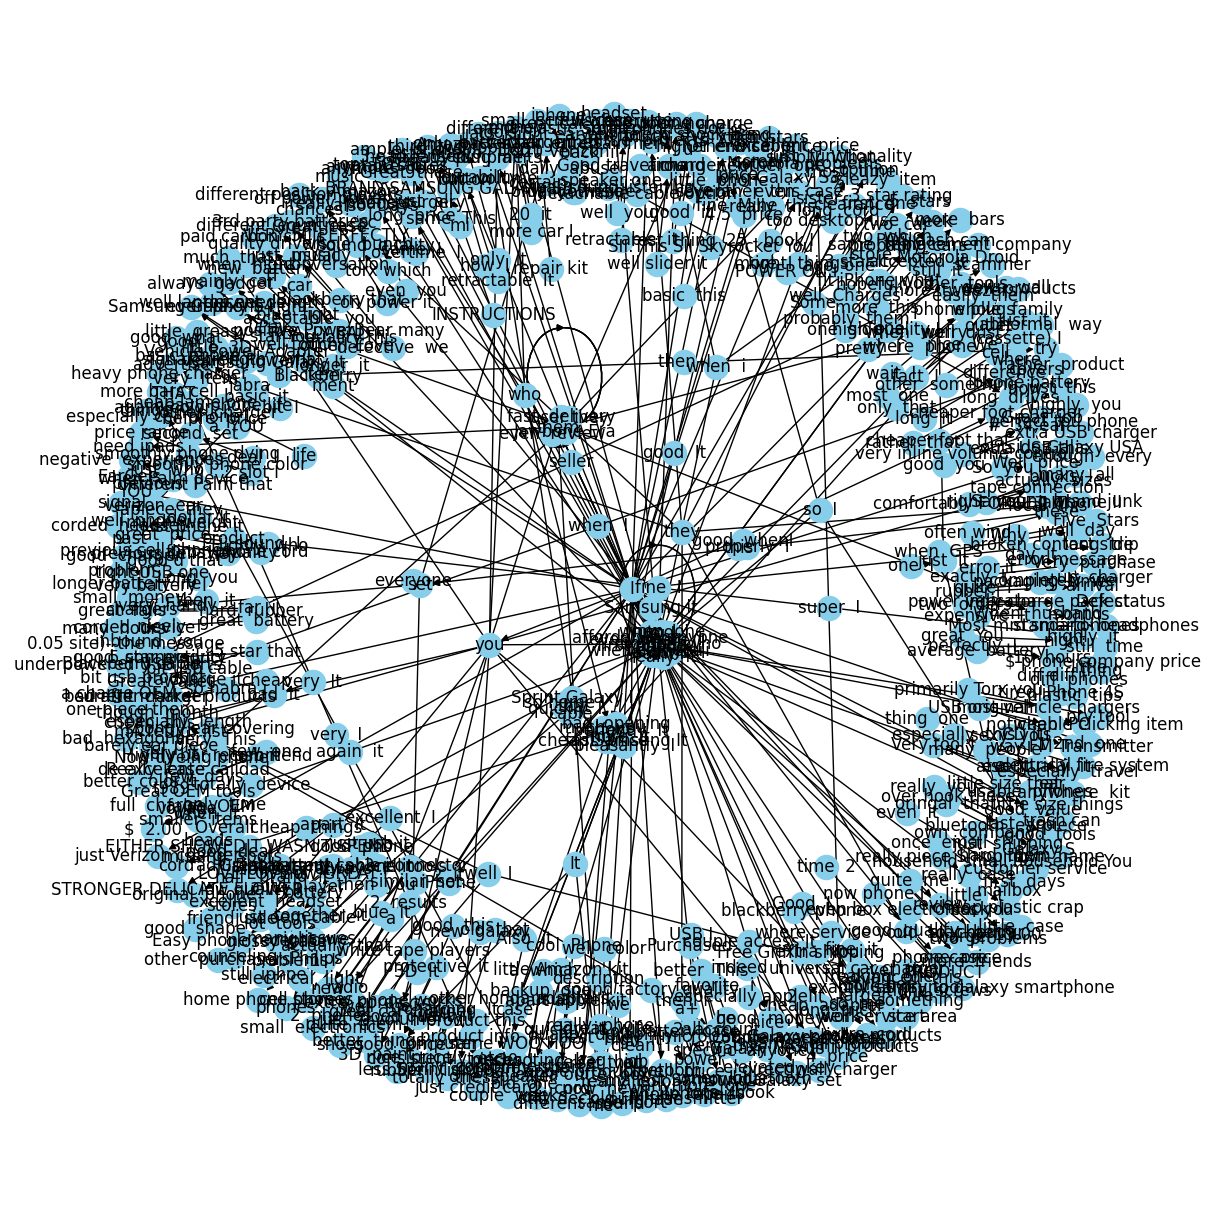

In [16]:
plt.figure(figsize=(12,12))

pos = nx.spring_layout(G)
nx.draw(G, with_labels=True, node_color='skyblue', edge_cmap=plt.cm.Blues, pos = pos)
plt.show()

In [20]:
kg_df["edge"][0:200]

0            buy
1          share
2        quality
3      been nice
4          helps
         ...    
195        think
196         work
197         need
198        known
199      am sure
Name: edge, Length: 200, dtype: object

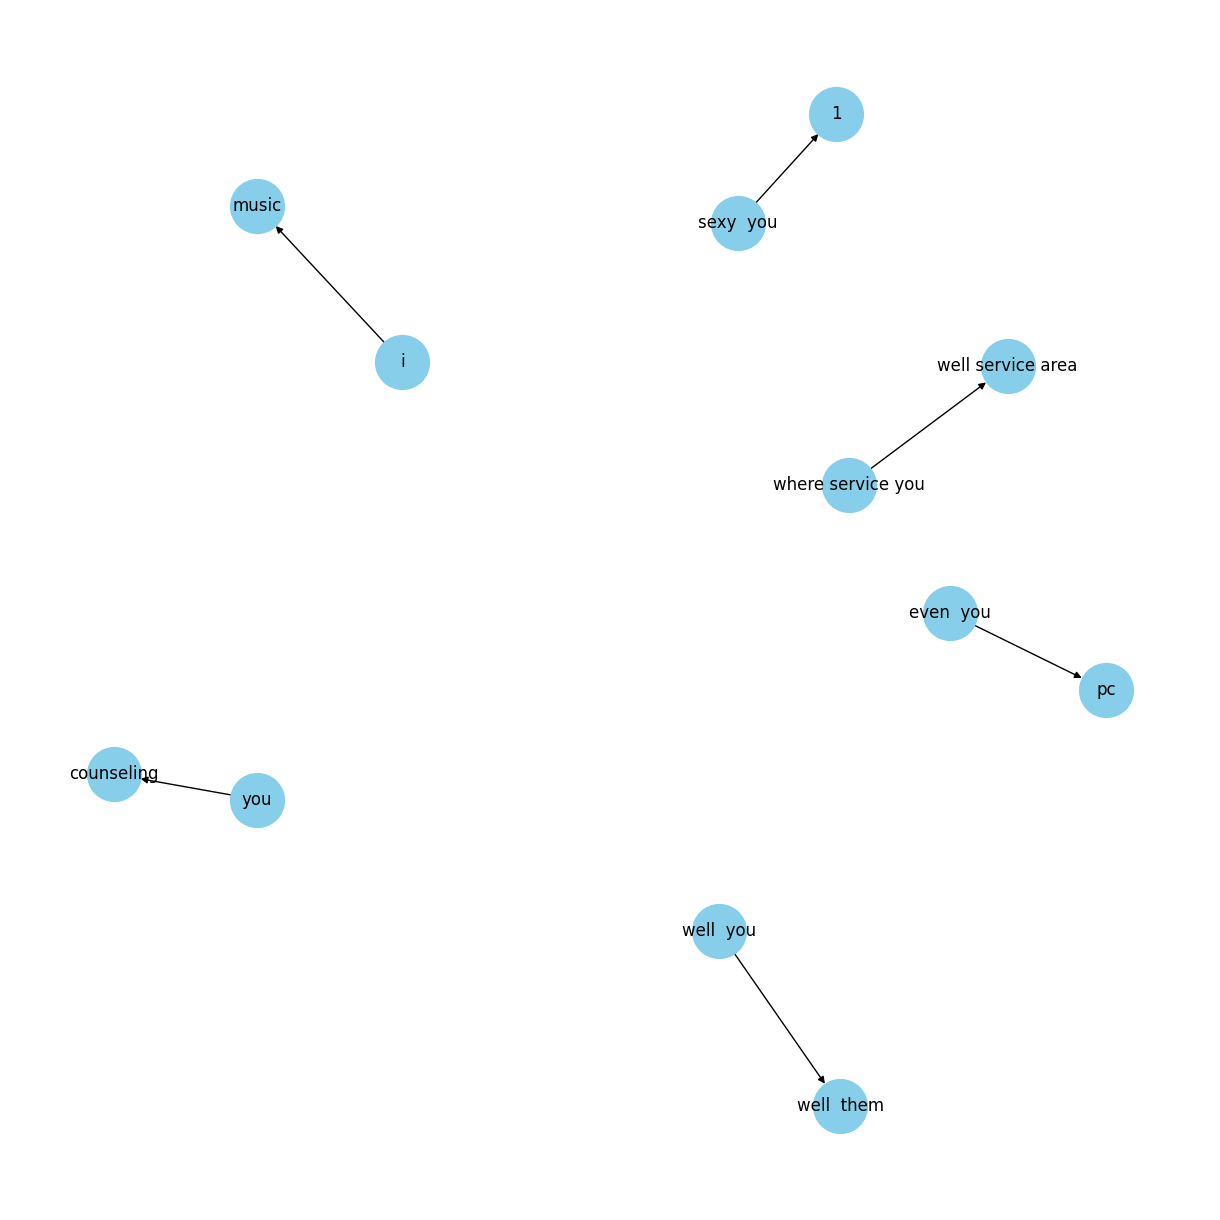

In [21]:
# filter only "need" relations and build directed graph
G = nx.from_pandas_edgelist(
    kg_df[kg_df['edge'] == "need"],  # keep only "need" edges
    "source", "target",
    edge_attr=True,
    create_using=nx.MultiDiGraph()
)

# set figure size
plt.figure(figsize=(12, 12))

# compute layout (node positioning)
pos = nx.spring_layout(G, k=0.5)

# draw graph
nx.draw(
    G,
    with_labels=True,
    node_color='skyblue',
    node_size=1500,
    edge_cmap=plt.cm.Blues,
    pos=pos
)

# show plot
plt.show()